# WxFlow: Conditional Flow Matching for Precipitation Downscaling

## Problem Statement and Dataset

Mountain precipitation is a critical input for climate adaptation planning, water resource management, and avalanche hazard assessment. However, general circulation models typically operate at ~100 km resolution and systematically fail to represent orographic precipitation effects in complex terrain. Dynamical downscaling via regional climate models such as the Weather Research and Forecasting (WRF) model can capture these fine-scale processes, but the computational cost—often requiring months of wall-clock time per climate scenario—severely limits the number of scenarios that can be evaluated in decision-support applications.

We develop **WxFlow**, a conditional generative model that learns to map coarse-resolution climate model output and high-resolution topographic information to ensembles of plausible high-resolution precipitation fields. By training a neural network velocity field via conditional flow matching, we enable rapid generation of probabilistically consistent downscaled precipitation in seconds rather than months, thereby enabling uncertainty quantification for climate adaptation at computationally tractable cost.

### Training and Evaluation Data

Training and evaluation data are derived from WRF simulations at 4 km horizontal resolution over the St. Elias and Chugach mountain ranges in southeastern Alaska. The dataset comprises maximum 3-day snowfall accumulations from multiple atmospheric forcings: CFSR reanalysis (1981–2010) for the historical baseline and GFDL CM3 and CCSM4 climate models (2031–2060) for future projections. We partition the temporal domain into 120 time steps for training and 30+ independent time steps for evaluation.

The data preprocessing pipeline implements three sequential operations: (1) spatial tiling, which decomposes the regional domain into overlapping 64×64 pixel patches to facilitate mini-batch training; (2) coarsening, which decimates the high-resolution precipitation field by a factor of 4 via block averaging to simulate 64 km resolution climate model output; and (3) conditioning, which concatenates the coarse precipitation, high-resolution topography, and pixel-wise validity masks as model inputs. This tiling-based approach balances the need to capture multi-scale precipitation structure with computational memory constraints.

In [1]:
import torch
import numpy as np
import os
import rasterio
from notebook_utils import block_mean_tensor_vectorized

class WRFDataLoader:
    def __init__(self, data_dir='./data',swe_factor=100.0,hgt_factor=300.0):
        self.data_dir = data_dir
        self.swe_factor = swe_factor
        self.hgt_factor = hgt_factor
    
        # Ensure data directory exists
        if not os.path.exists(self.data_dir):
            print(f"Creating data directory: {self.data_dir}")
            os.makedirs(self.data_dir)
    
        rasters = []
        filtered_files = []
        for f in os.listdir(data_dir):
            if '.tif' in f and 'HGT' not in f and 'aux' not in f:
                filtered_files.append(f)
        for f in filtered_files:
            try:
                data = rasterio.open(f'{data_dir}/{f}')
            except rasterio.RasterioIOError:
                continue
            snow = data.read().squeeze()[1:-1,1:-1]
            rasters.append(snow)

        cols, rows = np.meshgrid(np.arange(1,data.width-1), np.arange(1,data.height-1))
    
        # Convert entire grid to coordinates
        self.xs, self.ys = data.xy(rows, cols)
    
        self.rasters = np.stack(rasters,axis=0)
        self.rasters[self.rasters==-999] = np.nan
        self.rasters /= swe_factor
    
        self.rasters_test = self.rasters[120:]
        self.rasters = self.rasters[:120]
    
        self.d,self.h,self.w = self.rasters.shape
        self.d_test, _, _ = self.rasters_test.shape
        
    
        hgt = rasterio.open(f'{data_dir}/geo_southeast_4km_HGT.tif').read().squeeze()
        self.hgt = hgt[1:-1,1:-1] / hgt_factor

        self.xs = self.xs.reshape(self.h,self.w)
        self.ys = self.ys.reshape(self.h,self.w)       
    
    def sample(self, n, n_pix=64, device='cpu',test_set=False,return_coords=False):
    
        if test_set:
            d = self.d_test
        else:
            d = self.d
    
        images = []
        heights = []
        crses = []
        x_coords = []
        y_coords = []
        while len(images) < n:
          index = np.random.randint(d)
          h0 = np.random.randint(self.h - n_pix)
          w0 = np.random.randint(self.w - n_pix)
          if test_set:
              img = torch.tensor(self.rasters_test[index,h0:h0+n_pix,w0:w0+n_pix])
          else:
              img = torch.tensor(self.rasters[index,h0:h0+n_pix,w0:w0+n_pix])
          if torch.isnan(img).sum() < 0.3*n_pix**2:
              images.append(img)
              heights.append(torch.tensor(self.hgt[h0:h0+n_pix,w0:w0+n_pix]))
              x_coords.append(torch.tensor(self.xs[h0:h0+n_pix,w0:w0+n_pix]))
              y_coords.append(torch.tensor(self.ys[h0:h0+n_pix,w0:w0+n_pix]))
    
        image_batch = torch.stack(images).reshape(-1,1,n_pix,n_pix)
        hgt_batch = torch.stack(heights).reshape(-1,1,n_pix,n_pix)
        crs_batch = block_mean_tensor_vectorized(image_batch,4)
        x_batch = torch.stack(x_coords).reshape(-1,1,n_pix,n_pix)
        y_batch = torch.stack(y_coords).reshape(-1,1,n_pix,n_pix)

        if return_coords:
            return image_batch,hgt_batch,crs_batch,x_batch,y_batch
        else:
            return image_batch,hgt_batch,crs_batch
    
    def pull(self, locs, n_pix=64, device='cpu',test_set=False,return_coords=False):
    
        if test_set:
            d = self.d_test
        else:
            d = self.d
    
        images = []
        heights = []
        crses = []
        x_coords = []
        y_coords = []
        for index,h0,w0 in locs:
          if test_set:
              img = torch.tensor(self.rasters_test[index,h0:h0+n_pix,w0:w0+n_pix])
          else:
              img = torch.tensor(self.rasters[index,h0:h0+n_pix,w0:w0+n_pix])
          if torch.isnan(img).sum() < 0.3*n_pix**2:
              images.append(img)
              heights.append(torch.tensor(self.hgt[h0:h0+n_pix,w0:w0+n_pix]))
              x_coords.append(torch.tensor(self.xs[h0:h0+n_pix,w0:w0+n_pix]))
              y_coords.append(torch.tensor(self.ys[h0:h0+n_pix,w0:w0+n_pix]))
    
        image_batch = torch.stack(images).reshape(-1,1,n_pix,n_pix)
        hgt_batch = torch.stack(heights).reshape(-1,1,n_pix,n_pix)
        crs_batch = block_mean_tensor_vectorized(image_batch,4)
        x_batch = torch.stack(x_coords).reshape(-1,1,n_pix,n_pix)
        y_batch = torch.stack(y_coords).reshape(-1,1,n_pix,n_pix)    
        if return_coords:
            return image_batch,hgt_batch,crs_batch,x_batch,y_batch
        else:
            return image_batch,hgt_batch,crs_batch

n_pix = 64
target_model = WRFDataLoader(data_dir='./data/sx3/')
device = 'cuda'



Here we plot what a random sample from these data look like.  The topographic control is evident, as is the correlation with the predictions.

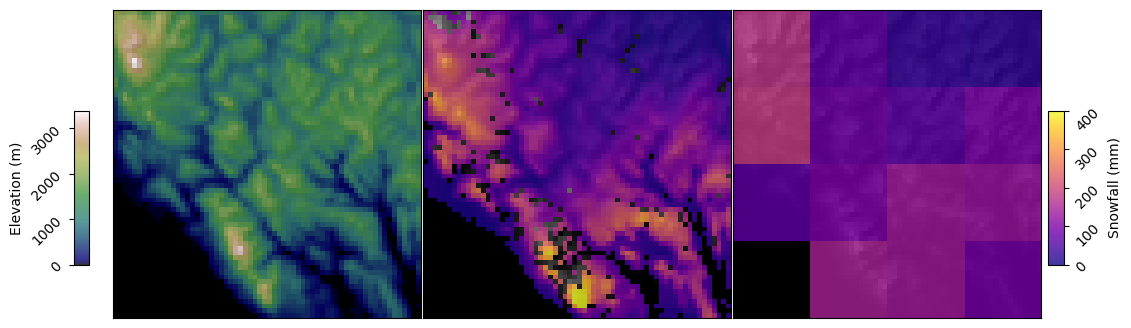

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_blended_hillshade(z_sample,ax,cmap=plt.cm.terrain,ve=1,dx=4000,vmin=-2.5,vmax=2.5):
   ls = LightSource(azdeg=315, altdeg=45)
   rgb = ls.shade(z_sample.numpy(), cmap=cmap, 
                  blend_mode='overlay', vert_exag=ve, 
                  dx=dx, dy=dx,vmin=vmin,vmax=vmax)
   ax.imshow(rgb)
    
hgt_factor = target_model.hgt_factor
swe_factor = target_model.swe_factor
x,h,c = target_model.sample(1,n_pix=n_pix)

fig,axs = plt.subplots(ncols=3)
for ax in axs.ravel():
    plot_blended_hillshade(h.cpu().squeeze()*swe_factor,ax,cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

c_hgt = axs[0].imshow(h.squeeze()*hgt_factor,cmap=plt.cm.gist_earth,alpha=0.8)
_     = axs[1].imshow(x.squeeze()*swe_factor,cmap=plt.cm.plasma,vmin=0.0,vmax=400.0,alpha=0.8)
c_swe = axs[2].imshow(c.squeeze()*swe_factor,cmap=plt.cm.plasma,vmin=0.0,vmax=400.0,alpha=0.8)

cax = inset_axes(axs[0], width="5%", height="50%", loc='lower left',bbox_to_anchor=(-0.15, 0.15, 1, 1), bbox_transform=axs[0].transAxes)
cbar = plt.colorbar(c_hgt,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.set_label('Elevation (m)')

cax = inset_axes(axs[2], width="5%", height="50%", loc='lower left',bbox_to_anchor=(1.0, 0.15, 1, 1), bbox_transform=axs[2].transAxes)
cbar = plt.colorbar(c_swe,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)
cbar.set_label('Snowfall (mm)')

fig.subplots_adjust(wspace=0,hspace=0)
fig.set_size_inches(12,4)


# Generative Modeling via Conditional Flow Matching

Conditional flow matching (CFM) is a framework for training generative models by learning velocity fields that interpolate between noise and data distributions. Unlike diffusion models, which reverse a fixed Markovian noise schedule, flow matching constructs probability paths via optimal transport, enabling more efficient training and faster sampling.

### Mathematical Framework

Given a high-resolution precipitation field $\mathbf{x}_1 \sim p_{\text{data}}$ and Gaussian noise $\mathbf{x}_0 \sim \mathcal{N}(0, \mathbf{I})$, the optimal transport probability path interpolates between these distributions:
$$\mathbf{x}_t = \sigma(t) \mathbf{x}_0 + \mu(t) \mathbf{x}_1$$

where $\sigma(t)$ and $\mu(t)$ are smooth monotonic functions satisfying $\sigma(0)=1, \mu(0)=0$ and $\sigma(1)=0, \mu(1)=1$. The velocity field in probability space is then:
$$\mathbf{v}(\mathbf{x}_t, t \mid \mathbf{c}) = \dot{\mu}(t) \mathbf{x}_1 - \dot{\sigma}(t) \mathbf{x}_0$$

where $\mathbf{c}$ denotes the conditioning information (coarse climate and topography). To train the generative model, we parameterize the velocity field $\mathbf{v}_\theta(\mathbf{x}_t, t \mid \mathbf{c})$ via a neural network and minimize the mean squared velocity prediction error:
$$\mathcal{L} = \mathbb{E}_{t, \mathbf{x}_1, \mathbf{x}_0, \mathbf{c}} \left\| \mathbf{v}_\theta(\mathbf{x}_t, t \mid \mathbf{c}) - \mathbf{v}(\mathbf{x}_t, t \mid \mathbf{c}) \right\|_2^2$$

masked to exclude pixels with missing precipitation data. This objective directly minimizes the distance between predicted and target velocity fields, providing a more stable optimization target than score matching used in diffusion models.

The following class builds the various quantities necessary for evaluating conditional probability paths, i.e. partially denoised random samples.

In [3]:
class OTProbabilityPaths:
    def __init__(self,sigma_0):
        self.sigma_0 = sigma_0

    def get_mu(self,x1,t):
        return x1*t

    def get_sigma(self,t):
        return 1 - (1 - self.sigma_0)*t

    def get_psi(self,x,x1,t):
        return self.get_sigma(t)*x + self.get_mu(x1,t)

    def get_v_target(self,x,x1,t):
        return x1 - (1-self.sigma_0)*x0

fm = OTProbabilityPaths(1e-3)

# Architecture: Conditional U-Net with Self-Attention

We employ a U-Net architecture with hierarchical feature extraction and self-attention mechanisms to approximate the conditional velocity field $\mathbf{v}_\theta$. The network is designed to balance computational efficiency with expressiveness sufficient to capture multi-scale precipitation patterns.

### Network Design

The architecture operates on 4-channel input concatenating (1) the partially denoised precipitation $\mathbf{x}_t$, (2) the high-resolution topography $z$, (3) the coarse-resolution climate model output $\bar{\mathbf{x}}_c$, and (4) a binary validity mask indicating missing data regions. The output is a single-channel velocity field prediction.

The forward pass follows the standard U-Net pattern: an initial convolution expands the spatial resolution to the base channel dimension, a sequence of downsampling blocks progressively reduce spatial resolution while increasing feature depth, a bottleneck layer applies processing at the coarsest resolution, and symmetric upsampling blocks with skip connections restore spatial resolution while progressively decreasing channels.

**Time conditioning:** Sinusoidal embeddings of the time variable $t$ are computed via:
$$\mathbf{e}_t^{(j)} = \begin{cases} \sin(10000^{-2j/d} \cdot t) & \text{if } j \text{ is even} \\ \cos(10000^{-2(j-1)/d} \cdot t) & \text{if } j \text{ is odd} \end{cases}$$

These embeddings are projected via an MLP and added to feature maps at each ResBlock, allowing the network to modulate feature processing as a function of the denoising progress.

**Multi-scale attention:** Self-attention layers are applied at 16×16 resolution (intermediate depth of the U-Net hierarchy), enabling the network to capture long-range spatial dependencies in precipitation patterns. This resolution balances the computational cost of attention operations with the need to model large-scale orographic forcing.

**Normalization and regularization:** Group normalization (with 32 groups) stabilizes training across variable batch sizes and provides robustness to initialization. Dropout is applied during training to regularize the network and reduce overfitting, particularly important given the modest dataset size.

In [4]:
from models.unet_models import UNet

in_channels = 4

v_model = UNet(
        in_channels=in_channels,
        model_channels=64,
        out_channels=1,
        num_res_blocks=2,
        attention_resolutions=(16,),  # Self-attention at 16x16 resolution
        channel_mult=(1, 1, 2, 3, 4,),   # Four resolution levels: 64, 32, 16, 8, 4
        dropout=0.1,
    ).to(device)

# Training Procedure

We train the velocity network via gradient descent on the velocity prediction loss (Equation 3 above) over mini-batches of (coarse, fine, topography) triplets sampled from the training set. 

**Optimization:** Adam optimizer with learning rate $2 \times 10^{-4}$, $\beta_1 = 0.9$, $\beta_2 = 0.999$.

**Data sampling:** Mini-batches of size 24 are randomly sampled from the 120 training time steps, with random spatial tiling applied at each iteration. To counteract the rapid initial signal decay early in the denoising trajectory, the time variable $t$ is sampled with bias toward the latter portion of the [0, 1] interval, increasing the relative importance of the refined precipitation features that emerge as $t \to 1$.

**Training duration:** 10,000 optimization steps, corresponding to approximately 2.5 epochs through the training dataset given the random tiling strategy.

**Masked loss:** The loss is computed only over pixels with valid (non-missing) precipitation observations, preventing the network from learning to predict velocity in regions where ground truth is unavailable. Checkpoints are saved every 100 steps to enable recovery from training interruption and model selection based on validation loss.

Set `TRAIN=True` to train from scratch (requires GPU, approximately 30 minutes). Set `TRAIN=False` to load pre-trained weights from the latest checkpoint.

In [7]:
TRAIN = False
if TRAIN:
    optimizer = torch.optim.Adam(v_model.parameters(),lr=1e-4)
    
    batch_size = 24
    n_steps = 10000

    beta = torch.distributions.beta.Beta(2,1)
    v_model.train()
    for i in range(n_steps):
        # Clear gradient buffer
        optimizer.zero_grad()

        # Sample from data points and associated conditioning
        x1,h,c = (f.to(device) for f in target_model.sample(batch_size,n_pix=n_pix))

        # mask any coarse resolution data
        c[c.isnan()] = 0.0

        # Build mask for unresolved high-res data - this will be a signal to ignore
        m = x1.isnan()  

        # Eliminate any nans
        x1[m] = 0.0

        # Sample time in [0,1]
        #t = torch.rand(x1.shape[0],1,1,1,device=device)
        t = beta.sample((x1.shape[0],1,1,1)).to(device)
        
        # Sample noise
        x0 = torch.randn_like(x1,device=device)

        # Extrapolate denoised image
        xt = fm.get_psi(x0,x1,t)

        # Build conditions - 
        # partially denoised image, topography, coarse climate, mask
        x_cat = torch.cat((xt,h,c,m),dim=1)

        # Predict velocity
        v_pred = v_model(x_cat,t.squeeze())

        # Get conditional velocity
        v_target = fm.get_v_target(x0,x1,t)

        # Compute loss, backprop, step
        loss = ((v_pred - v_target)**2)[~m].mean()
        loss.backward()
        optimizer.step()
        
        if i%1000==0:
            print(i,loss.item())
            torch.save(v_model,f'./checkpoints/conditional_snowfall_model_latest.pt')
            torch.save(v_model,f'./checkpoints/conditional_snowfall_model_{i:04d}.pt')
else:
    v_model = torch.load('./checkpoints/conditional_snowfall_model_beta.pt',weights_only=False)

# Generation via ODE Integration

Given a trained velocity network $\mathbf{v}_\theta$, we generate new samples by integrating an ordinary differential equation in probability space. Sampling from noise $\mathbf{x}_0(t=0) \sim \mathcal{N}(0, \mathbf{I})$ and integrating the learned velocity field:
$$\frac{d\mathbf{x}}{dt} = \mathbf{v}_\theta(\mathbf{x}(t), t \mid \mathbf{c})$$
from $t=0$ to $t=1$ with fixed conditioning $\mathbf{c}$ (coarse precipitation and topography), we obtain a sample $\mathbf{x}_1 = \mathbf{x}(t=1)$ from the learned conditional distribution. The ODE is integrated using an adaptive-step Runge-Kutta solver (DOPRI5) with relative and absolute tolerances of $10^{-5}$, requiring approximately 10 function evaluations per sample.

In [8]:
from torchdiffeq import odeint

# Number of samples to generate
n_samples = 3

# Draw some test set samples from a few tiles
xtrue,h,c = (f.to(device) for f in 
               target_model.pull([(29,0,0),(11,20,100),(5,50,220)],
               test_set=True))

# Mask coarse conditioning with nans
c[c.isnan()] = 0.0

# Set velocity model to eval mode
v_model.eval()

# Sample some noise
x0 = torch.randn(n_samples,1,n_pix,n_pix,device=device)

# Define the right-hand side for the flow-matching ODE
def func(t,x):
    xin = torch.cat((x,h,c,torch.zeros_like(x)),dim=1)
    return v_model(xin,t.reshape(1))

# Define integration interval
t = torch.linspace(0,1,50,device=device)

# Generate new samples via integration of the flow-matching ODE
# From noise initial conditions along trajectories defined
# by the velocity model
with torch.no_grad():
    trajectories = odeint(func, x0, t,rtol=1e-5,atol=1e-5)

# Finished samples occur at final time step
xsamp = trajectories[-1]


### Visual Comparison: Ensemble Downscaling versus Ground Truth and Baseline

The following visualizations compare WxFlow downscaled precipitation (ensemble mean), ground-truth high-resolution WRF simulations, and the low-resolution decimated forcing. Overlays on hillshade-enhanced topography highlight the spatial coherence of predicted patterns relative to topographic forcing.

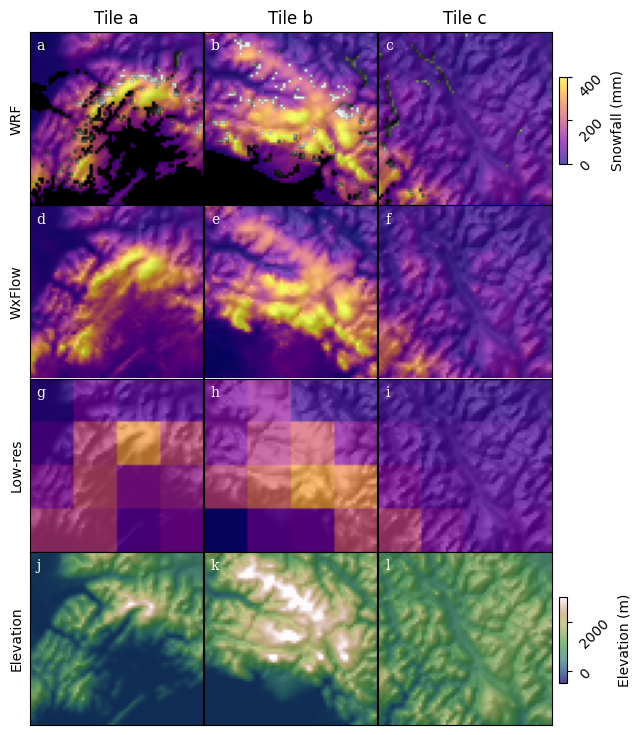

In [9]:
from matplotlib.colors import LightSource
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from string import ascii_lowercase


fig,axs = plt.subplots(nrows=4,ncols=n_samples)
for i in range(n_samples):
    plot_blended_hillshade(h[i].cpu().squeeze()*hgt_factor,axs[0,i],cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    plot_blended_hillshade(h[i].cpu().squeeze()*hgt_factor,axs[1,i],cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    plot_blended_hillshade(h[i].cpu().squeeze()*hgt_factor,axs[3,i],cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    plot_blended_hillshade(h[i].cpu().squeeze()*hgt_factor,axs[2,i],cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)

    cswe = axs[0,i].imshow(xtrue[i].cpu().squeeze()*swe_factor,vmin=0,vmax=400,cmap=plt.cm.plasma,alpha=0.7)
    _    = axs[1,i].imshow(xsamp[i].cpu().squeeze()*swe_factor,vmin=0,vmax=400,cmap=plt.cm.plasma,alpha=0.7)
    _    = axs[2,i].imshow(    c[i].cpu().squeeze()*swe_factor,vmin=0,vmax=400,cmap=plt.cm.plasma,alpha=0.7)
    chgt = axs[3,i].imshow(    h[i].cpu().squeeze()*hgt_factor,cmap=plt.cm.gist_earth,vmin=-500,vmax=3000,alpha=0.7)


    if i==n_samples-1:
        cax = inset_axes(axs[0,i], width="5%", height="50%", loc='lower left',bbox_to_anchor=(1.0, 0.2, 1, 1), bbox_transform=axs[0,i].transAxes)
        cbar = plt.colorbar(cswe,cax=cax,orientation='vertical')
        cbar.ax.tick_params(rotation=45)
        cbar.set_label('Snowfall (mm)')

        cax = inset_axes(axs[3,i], width="5%", height="50%", loc='lower left',bbox_to_anchor=(1.0, 0.2, 1, 1), bbox_transform=axs[3,i].transAxes)
        cbar = plt.colorbar(chgt,cax=cax,orientation='vertical')
        cbar.ax.tick_params(rotation=45)
        cbar.set_label('Elevation (m)')

for i,ax in enumerate(axs.ravel()):
    ax.xaxis.set_visible(False)
    ax.set_yticks([])
    ax.annotate(
        ascii_lowercase[i],
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif',
        color='white')

#axs[0,0].set_title('WRF', rotation='vertical',x=-0.1,y=0.3)
#axs[1,0].set_title('Flow matching', rotation='vertical',x=-0.1,y=0.3)
#axs[2,0].set_title('Low-res', rotation='vertical',x=-0.1,y=0.3)
#axs[3,0].set_title('Elevation', rotation='vertical',x=-0.1,y=0.3)

axs[0,0].set_ylabel('WRF')#, rotation='vertical',x=-0.1,y=0.3)
axs[1,0].set_ylabel('WxFlow')#, rotation='vertical',x=-0.1,y=0.3)
axs[2,0].set_ylabel('Low-res')#, rotation='vertical',x=-0.1,y=0.3)
axs[3,0].set_ylabel('Elevation')#, rotation='vertical',x=-0.1,y=0.3)

axs[0,0].set_title('Tile a')
axs[0,1].set_title('Tile b')
axs[0,2].set_title('Tile c')

fig.set_size_inches(9*3/4.,9)
fig.subplots_adjust(wspace=0,hspace=0)
fig.savefig('concept/figures/wrf_flow_comparison.png',dpi=300,bbox_inches='tight')

For spatial reference, we plot the location of these tiles on a reference map of Alaska:

Projection: unnamed


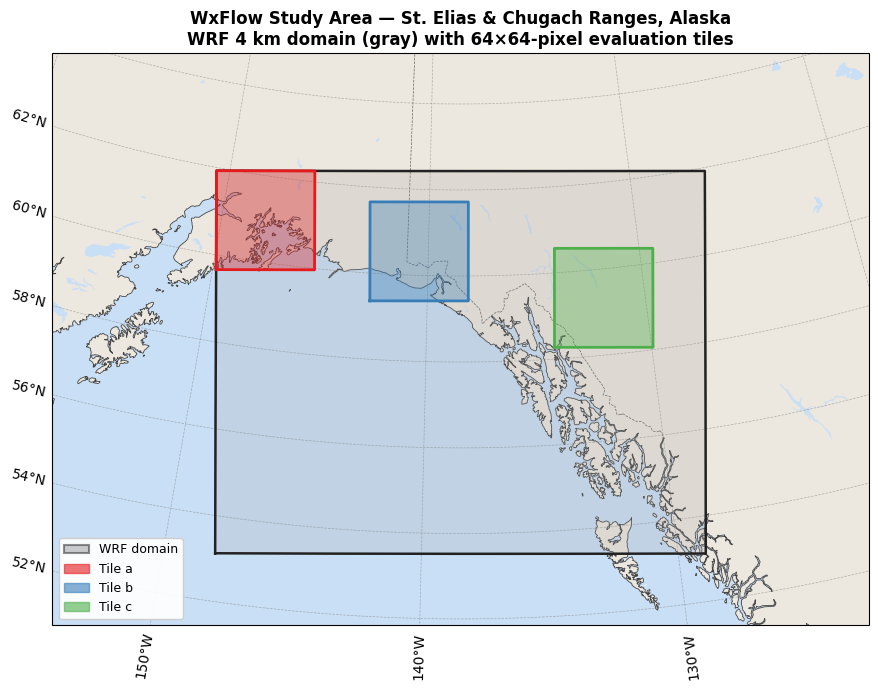

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Study-area basemap: Alaska overview with WRF domain and evaluation tiles
# ─────────────────────────────────────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import CRS, Transformer

# ── 1. CRS from the first .tif found in data/sx3 ─────────────────────────────
#    (equivalent to reading the spatialref / crs_wkt field from the file)
sx3_dir = './data/sx3'
_tif = next(f for f in sorted(os.listdir(sx3_dir))
            if f.endswith('.tif') and 'aux' not in f)
with rasterio.open(os.path.join(sx3_dir, _tif)) as _src:
    _crs_wkt = _src.crs.wkt

proj_crs  = CRS.from_wkt(_crs_wkt)
to_lonlat = Transformer.from_crs(proj_crs, CRS.from_epsg(4326), always_xy=True)
print(f"Projection: {proj_crs.name}")

# ── 2. Tile locations (time_idx, h0, w0) – from pull() call in notebook ───────
_n_pix        = 64
_locs         = [(29, 0, 0), (11, 20, 100), (5, 50, 220)]
_tile_colors  = ['#e41a1c', '#377eb8', '#4daf4a']
_tile_labels  = ['Tile a',
                 'Tile b',
                 'Tile c']

# Projected coordinate grids from the already-loaded data loader
_xs = target_model.xs   # shape (H, W)  – easting,  native CRS
_ys = target_model.ys   # shape (H, W)  – northing, native CRS

# ── 3. Helper: densified projected box → lon/lat polygon ─────────────────────
def _proj_box_to_lonlat(h0, w0, n_pix, xs, ys, tfm, n_edge=80):
    """Return (lons, lats) arrays tracing the tile boundary in lon/lat."""
    tx, ty = xs[h0:h0+n_pix, w0:w0+n_pix], ys[h0:h0+n_pix, w0:w0+n_pix]
    hdx = abs(float(xs[0, 1] - xs[0, 0])) / 2   # half a pixel in x
    hdy = abs(float(ys[1, 0] - ys[0, 0])) / 2   # half a pixel in y
    x0_, x1 = float(tx.min()) - hdx, float(tx.max()) + hdx
    y0_, y1 = float(ty.min()) - hdy, float(ty.max()) + hdy
    t = np.linspace(0, 1, n_edge, endpoint=False)
    # Traverse: bottom → right → top (reversed) → left (reversed)
    px = np.concatenate([x0_ + t*(x1-x0_), np.full(n_edge, x1),
                         x1  - t*(x1-x0_), np.full(n_edge, x0_)])
    py = np.concatenate([np.full(n_edge, y0_), y0_ + t*(y1-y0_),
                         np.full(n_edge, y1),  y1  - t*(y1-y0_)])
    return tfm.transform(px, py)   # (lons, lats)

# ── 4. WRF domain outline (densified rectangle in projected space) ─────────────
_n_d  = 200
_t    = np.linspace(0, 1, _n_d, endpoint=False)
_hdx  = abs(float(_xs[0, 1] - _xs[0, 0])) / 2
_hdy  = abs(float(_ys[1, 0] - _ys[0, 0])) / 2
_xmin, _xmax = float(_xs.min()) - _hdx, float(_xs.max()) + _hdx
_ymin, _ymax = float(_ys.min()) - _hdy, float(_ys.max()) + _hdy
_dpx = np.concatenate([_xmin + _t*(_xmax-_xmin), np.full(_n_d, _xmax),
                       _xmax - _t*(_xmax-_xmin), np.full(_n_d, _xmin)])
_dpy = np.concatenate([np.full(_n_d, _ymin), _ymin + _t*(_ymax-_ymin),
                       np.full(_n_d, _ymax), _ymax - _t*(_ymax-_ymin)])
_dom_lons, _dom_lats = to_lonlat.transform(_dpx, _dpy)

# ── 5. Map extent derived from domain + padding ────────────────────────────────
_pad_lon, _pad_lat = 3.0, 2.0
_extent = [_dom_lons.min() - _pad_lon, _dom_lons.max() + _pad_lon,
           _dom_lats.min() - _pad_lat, _dom_lats.max() + _pad_lat]
_clon   = (_extent[0] + _extent[1]) / 2
_clat   = (_extent[2] + _extent[3]) / 2

# ── 6. Plot ────────────────────────────────────────────────────────────────────
fig_bm, ax_bm = plt.subplots(
    figsize=(10, 7),
    subplot_kw=dict(projection=ccrs.AlbersEqualArea(
        central_longitude=_clon, central_latitude=_clat,
        standard_parallels=(55, 65))))

ax_bm.set_extent(_extent, crs=ccrs.PlateCarree())

ax_bm.add_feature(cfeature.LAND,      facecolor='#ede8df', zorder=0)
ax_bm.add_feature(cfeature.OCEAN,     facecolor='#c9dff5', zorder=0)
ax_bm.add_feature(cfeature.LAKES,     facecolor='#c9dff5', zorder=1)
ax_bm.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='#444', zorder=2)
ax_bm.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle='--',
                  edgecolor='#666', zorder=2)

# WRF domain
ax_bm.fill(np.append(_dom_lons, _dom_lons[0]),
           np.append(_dom_lats, _dom_lats[0]),
           color='#999', alpha=0.18, transform=ccrs.PlateCarree(), zorder=3)
ax_bm.plot(np.append(_dom_lons, _dom_lons[0]),
           np.append(_dom_lats, _dom_lats[0]),
           '-', color='#222', linewidth=1.8, transform=ccrs.PlateCarree(), zorder=3)

# Evaluation tiles
for (_, h0, w0), color, label in zip(_locs, _tile_colors, _tile_labels):
    lons, lats = _proj_box_to_lonlat(h0, w0, _n_pix, _xs, _ys, to_lonlat)
    ax_bm.fill(np.append(lons, lons[0]), np.append(lats, lats[0]),
               facecolor=color, alpha=0.35,
               transform=ccrs.PlateCarree(), zorder=4)
    ax_bm.plot(np.append(lons, lons[0]), np.append(lats, lats[0]),
               '-', color=color, linewidth=2.0,
               transform=ccrs.PlateCarree(), zorder=4)

# Grid lines
gl = ax_bm.gridlines(draw_labels=True, linewidth=0.5, linestyle='--',
                     alpha=0.55, color='gray', x_inline=False, y_inline=False)
gl.top_labels  = False
gl.right_labels = False

# Legend
_legend_handles = [
    mpatches.Patch(facecolor='#999', edgecolor='#222', linewidth=1.5,
                   alpha=0.5, label='WRF domain'),
] + [
    mpatches.Patch(facecolor=c, edgecolor=c, alpha=0.6, label=lbl)
    for c, lbl in zip(_tile_colors, _tile_labels)
]
ax_bm.legend(handles=_legend_handles, loc='lower left', fontsize=9, framealpha=0.92)
ax_bm.set_title(
    'WxFlow Study Area — St. Elias & Chugach Ranges, Alaska\n'
    'WRF 4 km domain (gray) with 64×64-pixel evaluation tiles',
    fontsize=12, fontweight='bold')

plt.tight_layout()
fig_bm.savefig('concept/figures/basemap.png', dpi=300, bbox_inches='tight')
plt.show()

# Ensemble Variability and Uncertainty Quantification

By generating multiple independent realizations with different noise samples, we obtain an ensemble that characterizes the conditional probability distribution over the downscaling problem. The ensemble variability reflects both (1) the aleatoric uncertainty inherent to the downscaling problem—given coarse forcing and topography, multiple physically plausible fine-scale solutions exist—and (2) the epistemic uncertainty captured by the learned conditional distribution based on training data. The spatial pattern of ensemble spread provides diagnostic information about which regions have high predictability (low spread) and which regions have intrinsic unpredictability relative to the coarse forcing (high spread).  Of particular note, we find that deviations from the mean exhibit strong spatial coherence relative to topography, and orographic effects are clearly visible.

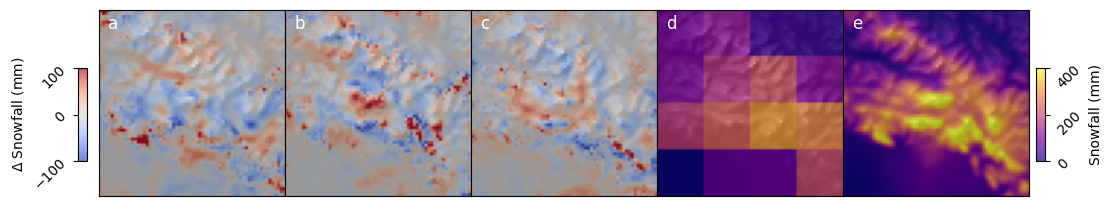

In [12]:
n_samples = 50
xtrue,h,c = (f.to(device) for f in 
               target_model.pull([(11,20,100)],
               test_set=True))

c[c.isnan()] = 0.0

xtrue = torch.tile(xtrue,(n_samples,1,1,1))
h = torch.tile(h,(n_samples,1,1,1))
c = torch.tile(c,(n_samples,1,1,1))

v_model.eval()

x0 = torch.randn(n_samples,1,n_pix,n_pix,device=device)

def func(t,x):
    xin = torch.cat((x,h,c,torch.zeros_like(x)),dim=1)
    return v_model(xin,t.reshape(1))

t = torch.linspace(0,1,10,device=device)
with torch.no_grad():
    trajectories = odeint(func, x0, t,rtol=1e-5,atol=1e-5)

xsamp = trajectories[-1]
xmean = xsamp.mean(dim=0)
xdelta = xsamp - xmean

fig,axs = plt.subplots(nrows=1,ncols=5)
axs = axs.ravel()
letters = 'abcde'
lc = 0

for ax in axs.ravel():
    plot_blended_hillshade(h[i].cpu().squeeze()*swe_factor,ax,cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    

for i in range(3):    
    c_delta = axs[i].imshow(xdelta[i].cpu().squeeze()*swe_factor,vmin=-100,vmax=100,alpha=0.7,cmap=plt.cm.coolwarm)

    axs[i].text(0.05, 0.9, letters[lc],color='white',transform=axs[i].transAxes,fontsize=12)
    lc+=1

cax = inset_axes(axs[0], width="5%", height="50%", loc='lower left',bbox_to_anchor=(-0.15, 0.15, 1, 1), bbox_transform=axs[0].transAxes)
cbar = plt.colorbar(c_delta,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)#,color='white', labelcolor='white')
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.set_label('$\\Delta$ Snowfall (mm)')

axs[3].imshow(c[0].cpu().squeeze()*swe_factor,vmin=0,vmax=400,alpha=0.7,cmap=plt.cm.plasma)
axs[3].text(0.05, 0.9, letters[3],color='white',transform=axs[3].transAxes,fontsize=12)

c_abs = axs[4].imshow(xmean.cpu().squeeze()*swe_factor,vmin=0,vmax=400,alpha=0.7,cmap=plt.cm.plasma)
cax = inset_axes(axs[4], width="5%", height="50%", loc='lower left',bbox_to_anchor=(1.0, 0.15, 1, 1), bbox_transform=axs[4].transAxes)
cbar = plt.colorbar(c_abs,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)
cbar.set_label('Snowfall (mm)')

axs[4].text(0.05, 0.9, letters[4],color='white',transform=axs[4].transAxes,fontsize=12)

fig.set_size_inches(12,6)
fig.subplots_adjust(wspace=0,hspace=0)
fig.savefig('concept/figures/spatial_coherence.png',dpi=300,bbox_inches='tight')

# Ensemble Statistics and Probabilistic Predictions

A key advantage of the generative approach is the ability to draw multiple independent samples from the learned conditional distribution. By sampling different realizations of the noise $\mathbf{x}_0$ and integrating the learned velocity field with the same conditioning information, we generate an ensemble of precipitation realizations consistent with both the coarse climate forcing and the high-resolution topography.

For a given set of conditioning inputs (coarse precipitation and topography), the ensemble $\{\hat{\mathbf{x}}^{(i)}_1\}_{i=1}^{N}$ provides a Monte Carlo approximation of the conditional probability distribution $p(\mathbf{x}_1 \mid \mathbf{c})$. The ensemble mean serves as a point estimate of the conditional expectation, while the ensemble standard deviation quantifies spatial uncertainty patterns.

Analysis of ensemble statistics reveals important structure: (1) The mean field captures the large-scale orographic forcing evident in the coarse climate model output, refined with topography-dependent detail; (2) Uncertainty (standard deviation) exhibits spatial heterogeneity, with elevated spread over complex terrain where precipitation processes are most difficult to predict from coarse data, and reduced spread over homogeneous regions where the coarse forcing dominates.

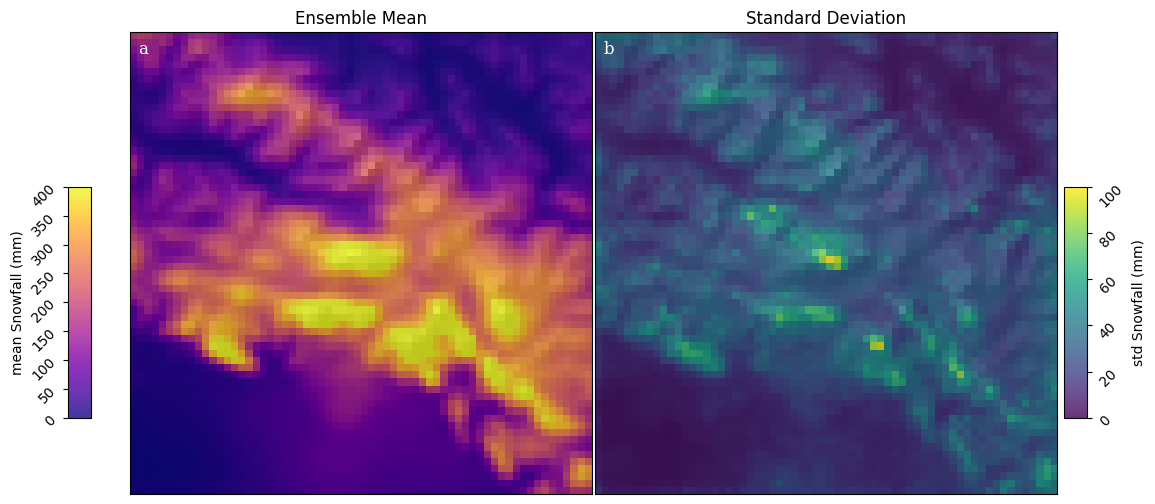

In [13]:
fig,axs = plt.subplots(nrows=1,ncols=2)
for i,ax in enumerate(axs.ravel()):
    plot_blended_hillshade(h[i].cpu().squeeze()*swe_factor,ax,cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.annotate(
        ascii_lowercase[i],
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='serif',
        color='white')

axs[0].set_title('Ensemble Mean')
axs[1].set_title('Standard Deviation')

c_mean = axs[0].imshow(xsamp.mean(axis=0).squeeze().cpu()*swe_factor,vmin=0,vmax=400,alpha=0.8,cmap=plt.cm.plasma)
c_std  = axs[1].imshow(xsamp.std(axis=0).squeeze().cpu()*swe_factor,vmin=0,vmax=100,alpha=0.8)

cax = inset_axes(axs[0], width="5%", height="50%", loc='lower left',bbox_to_anchor=(-0.15, 0.15, 1, 1), bbox_transform=axs[0].transAxes)
cbar = plt.colorbar(c_mean,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.set_label('mean Snowfall (mm)')

cax = inset_axes(axs[1], width="5%", height="50%", loc='lower left',bbox_to_anchor=(1.0, 0.15, 1, 1), bbox_transform=axs[1].transAxes)
cbar = plt.colorbar(c_std,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)
cbar.set_label('std Snowfall (mm)')


fig.set_size_inches(12,6)
fig.subplots_adjust(wspace=0,hspace=0)
fig.savefig('concept/figures/summary_statistics.png',dpi=300,bbox_inches='tight')

# Evaluation 1: Continuous Ranked Probability Score (CRPS)

The Continuous Ranked Probability Score (CRPS) is a proper scoring rule that measures the calibration of probabilistic predictions, penalizing both forecast bias and overconfidence. For an ensemble forecast with $N$ members $\{\hat{x}^{(i)}\}_{i=1}^N$ and a scalar observation $y$, the CRPS is defined as:

$$\text{CRPS} = \mathbb{E}_{F}\left|F - y\right| - \frac{1}{2}\mathbb{E}_{F, F'}\left|F - F'\right|$$

where $F$ and $F'$ are independent samples from the forecast distribution. For an ensemble sample, this decomposes into:
$$\text{CRPS}_{\text{ens}} = \frac{1}{N}\sum_{i=1}^{N} \left|\hat{x}^{(i)} - y\right| - \frac{1}{2N(N-1)}\sum_{i=1}^{N}\sum_{j \neq i} \left|\hat{x}^{(i)} - \hat{x}^{(j)}\right|$$

The first term penalizes distance to the observation (reliability), while the second term is a penalty on ensemble spread (resolution). Lower CRPS indicates better forecast skill.

### Baseline Comparison

To contextualize the WxFlow predictions, we construct a statistical baseline via Bayesian linear regression. Given the high-resolution topography $z$ and coarse climate field $\bar{\mathbf{x}}_c$, we posit a linear predictive model:
$$\hat{\mathbf{x}}_{\text{pred}} = \omega_0 z + \omega_1 \bar{\mathbf{x}}_c + \omega_2$$

with unknown coefficients $\boldsymbol{\omega} = (\omega_0, \omega_1, \omega_2)^T$. We infer these parameters via Bayesian linear regression, assuming a prior that favors moderate regularization and a likelihood with structured noise (accounting for both systematic model inadequacy and random error). Ensemble predictions are then generated by sampling from the posterior distribution over $\boldsymbol{\omega}$. This approach provides a strong baseline that accounts for the fundamental topographic and coarse-scale climate relationships in the training data, against which the more complex flow matching model can be compared.

In [14]:
# To compare crps, we need an alternative model
x1,h,c = (f.to(device) for f in target_model.sample(60,n_pix=n_pix))
c[c.isnan()] = 0.0
scale = 16

import torch.nn.functional as F
c_interp = F.interpolate(c[:,:,::scale,::scale], scale_factor=scale, mode='bicubic', align_corners=False)

h_flat = h.ravel()
c_flat = c_interp.ravel()
x1_flat = x1.ravel()

m_flat = x1_flat.isnan()

h_flat = h_flat[~m_flat]
c_flat = c_flat[~m_flat]
x1_flat = x1_flat[~m_flat]

phi = torch.vstack((h_flat,c_flat,torch.ones(len(h_flat),device=device))).T

tau_obs = 100
v = torch.ones(phi.shape[0],1,device=device)
K = tau_obs*(phi.T @ phi - (phi.T @ v) @ (v.T @ phi)/(1 + v.T @ v))
z = tau_obs*(phi.T @ (x1_flat - v @ (v.T @ x1_flat)/(1 + v.T @ v)).T)

L = torch.linalg.cholesky(K)
w_opt = torch.linalg.solve(K,z)

With this trained alternative model in hand, we can compute the CRPS for both models.  

In [15]:
torch.manual_seed(0)

def compute_crps(ensemble_samples, observations, axis=None):
    """
    Compute Continuous Ranked Probability Score.
    
    Args:
        ensemble_samples: Array of shape (n_members, *spatial_dims) 
                         or (n_members, n_locations)
        observations: Array of shape (*spatial_dims,) or (n_locations,)
        axis: Axis over which to compute ensemble statistics (default: axis 0)
    
    Returns:
        CRPS score(s) - lower is better
    """
    # First term: mean absolute error to observation
    ae = np.abs(ensemble_samples - observations)
    term1 = np.mean(ae, axis=0)
    
    # Second term: half the mean pairwise ensemble distance
    # For computational efficiency, compute as: 
    # 0.5 * E[|F_i - F_j|] = sum of pair distances / (2 * n_pairs)
    n_members = ensemble_samples.shape[0]
    term2 = np.zeros_like(term1)
    
    for i in range(n_members):
        for j in range(i + 1, n_members):
            term2 += np.abs(ensemble_samples[i] - ensemble_samples[j])
    
    term2 = term2 / (n_members * (n_members - 1) / 2.0)
    
    return term1 - 0.5 * term2

# Generate a large ensemble for evaluation
n_eval_samples = 50

#xtrue_eval, h_eval, c_eval = (f.to(device) for f in 
#                               target_model.sample(5,n_pix=n_pix,
#                               test_set=True))

# Draw some test set samples from a few tiles
xtrue_eval,h_eval,c_eval = (f.to(device) for f in 
               target_model.pull([(29,0,0),(11,20,100),(5,50,220)],
               test_set=True))

mask = xtrue_eval.isnan()

# Prepare tensors for ensemble generation
c_eval[c_eval.isnan()] = 0.0
n_tiles = xtrue_eval.shape[0]

# Expand for ensemble
xtrue_ensemble = xtrue_eval.repeat(n_eval_samples, 1, 1, 1)
h_ensemble = h_eval.repeat(n_eval_samples, 1, 1, 1)
c_ensemble = c_eval.repeat(n_eval_samples, 1, 1, 1)

v_model.eval()

# Generate ensemble via ODE integration
x0_eval = torch.randn(n_eval_samples * n_tiles, 1, n_pix, n_pix, device=device)

def func_eval(t, x):
    xin = torch.cat((x, h_ensemble.reshape(-1, 1, n_pix, n_pix), 
                     c_ensemble.reshape(-1, 1, n_pix, n_pix),
                     torch.zeros_like(x)), dim=1)
    return v_model(xin, t.reshape(1))

t_eval = torch.linspace(0, 1, 100, device=device)

with torch.no_grad():
    trajectories_eval = odeint(func_eval, x0_eval, t_eval, rtol=1e-5, atol=1e-5)

xsamp_ensemble = trajectories_eval[-1].reshape(n_eval_samples, n_tiles, 1, n_pix, n_pix)

# Compute CRPS
crps_flow = compute_crps(
    xsamp_ensemble.cpu().numpy() * swe_factor,
    xtrue_eval.cpu().numpy() * swe_factor
)

# Baseline: CRPS from bicubic interpolated coarse climate
c_bicubic = F.interpolate(c_ensemble[:,:,::16,::16], scale_factor=16, mode='bicubic', align_corners=False)
noise = torch.randn(3,150,device=device)
w_samples = w_opt + torch.linalg.solve_triangular(L,noise,upper=False)
xsamp_bicubic = (h_ensemble * w_samples[0].reshape(-1,1,1,1) + 
                 c_bicubic*w_samples[1].reshape(-1,1,1,1) + 
                 w_samples[2].reshape(-1,1,1,1)).reshape(n_eval_samples,n_tiles,1,n_pix,n_pix)

crps_coarse = compute_crps(
    xsamp_bicubic.cpu().numpy() * swe_factor,
    xtrue_eval.cpu().numpy() * swe_factor
)

print(f"WxFlow CRPS (ensemble of {n_eval_samples}):")
print(f"  Mean CRPS: {np.nanmean(crps_flow):.2f} mm")
print(f"  Std CRPS:  {np.nanstd(crps_flow):.2f} mm")
print(f"\nCoarse baseline CRPS (interpolated):")
print(f"  Mean CRPS: {np.nanmean(crps_coarse):.2f} mm")
print(f"  Improvement: {(np.nanmean(crps_coarse) - np.nanmean(crps_flow)) / np.nanmean(crps_coarse) * 100:.1f}%")

WxFlow CRPS (ensemble of 50):
  Mean CRPS: 13.74 mm
  Std CRPS:  17.20 mm

Coarse baseline CRPS (interpolated):
  Mean CRPS: 29.01 mm
  Improvement: 52.6%


### Spatial Evaluation of Forecast Skill

The global CRPS metrics demonstrate substantial reduction in forecast error relative to the statistical baseline. Below we visualize pointwise CRPS to identify spatial heterogeneity in prediction difficulty, revealing regions where the flow matching model most substantially improves upon the statistical downscaling approach.  Improvement is particularly evident in regions of complex topography, where the simple relationship between long-wavelength atmospheric state and topography is insufficient to capture orographic precipitation effects.  

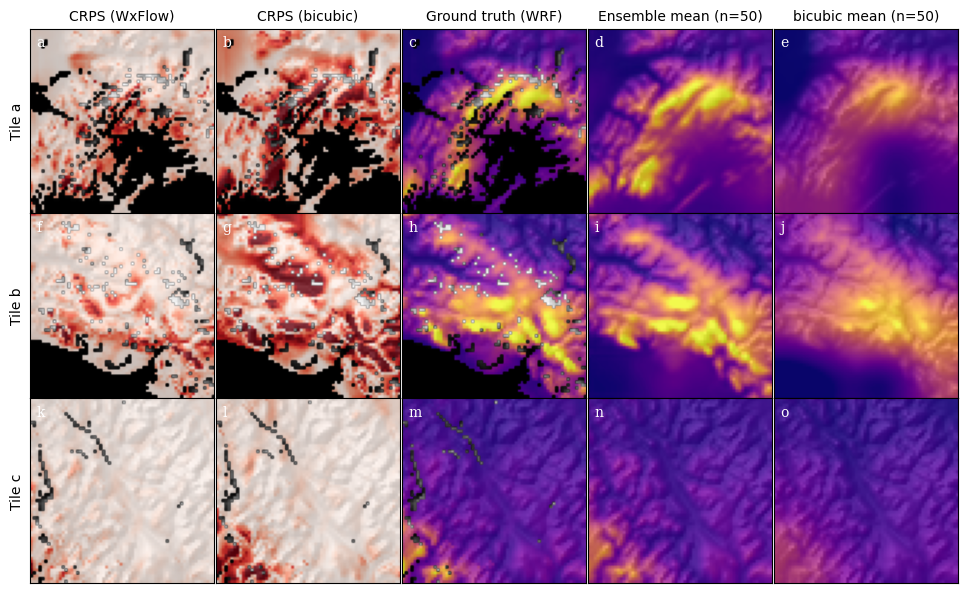

In [19]:
# Spatial visualization of CRPS
fig, axs = plt.subplots(nrows=n_tiles, ncols=5, figsize=(12, 2.4*n_tiles))

if n_tiles == 1:
    axs = axs.reshape(1, -1)

for tile_idx in range(n_tiles):
    # Plot elevation as background
    for ax_idx in range(5):
        plot_blended_hillshade(h_eval[tile_idx].cpu().squeeze() * hgt_factor, 
                              axs[tile_idx, ax_idx], 
                              cmap=plt.cm.grey, vmin=0, vmax=3000, ve=100)
        axs[tile_idx, ax_idx].xaxis.set_visible(False)
        axs[tile_idx, ax_idx].set_yticks([])#yaxis.set_visible(False)
    
    # CRPS spatial map
    c_crps = axs[tile_idx, 0].imshow(crps_flow[tile_idx, 0], 
                                      cmap=plt.cm.Reds, vmin=0, vmax=100, alpha=0.8)
    if tile_idx==0:
        axs[tile_idx, 0].set_title('CRPS (WxFlow)', fontsize=10)

    # CRPS spatial map
    c_crps = axs[tile_idx, 1].imshow(crps_coarse[tile_idx, 0], 
                                      cmap=plt.cm.Reds, vmin=0, vmax=100, alpha=0.8)
    if tile_idx==0:
        axs[tile_idx, 1].set_title('CRPS (bicubic)', fontsize=10)
    
    # True observation
    c_true = axs[tile_idx, 2].imshow(xtrue_eval[tile_idx].squeeze().cpu() * swe_factor,
                                      cmap=plt.cm.plasma, vmin=0, vmax=400, alpha=0.8)
    if tile_idx==0:
        axs[tile_idx, 2].set_title('Ground truth (WRF)', fontsize=10)
    
    # Ensemble mean
    c_mean = axs[tile_idx, 3].imshow(np.mean(xsamp_ensemble[:, tile_idx, 0].cpu().numpy() * swe_factor, axis=0),
                                      cmap=plt.cm.plasma, vmin=0, vmax=400, alpha=0.8)
    if tile_idx==0:
        axs[tile_idx, 3].set_title(f'Ensemble mean (n={n_eval_samples})', fontsize=10)

    # Ensemble mean
    c_mean = axs[tile_idx, 4].imshow(np.mean(xsamp_bicubic[:, tile_idx, 0].cpu().numpy() * swe_factor, axis=0),
                                      cmap=plt.cm.plasma, vmin=0, vmax=400, alpha=0.8)
    if tile_idx==0:
        axs[tile_idx, 4].set_title(f'bicubic mean (n={n_eval_samples})', fontsize=10)




for i,ax in enumerate(axs.ravel()):
    ax.annotate(
        ascii_lowercase[i],
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif',
        color='white')

axs[0,0].set_ylabel('Tile a')
axs[1,0].set_ylabel('Tile b')
axs[2,0].set_ylabel('Tile c')

fig.subplots_adjust(wspace=0,hspace=0)
fig.savefig('concept/figures/crps.png',dpi=300,bbox_inches='tight')

# Evaluation 2: Power Spectral Density and Spatial Structure Fidelity

While CRPS assesses point-wise forecast calibration, the spatial structure of downscaled precipitation is equally important for applications in hydrology and hazard assessment. We evaluate spatial structure fidelity via the radially-averaged two-dimensional power spectral density (PSD), which decomposes variance as a function of spatial wavelength.

### Spectral Analysis Framework

The two-dimensional discrete Fourier transform of a precipitation field $\mathbf{x}(i, j)$ on an $n \times n$ grid yields wavenumber components. The power spectral density is defined as:
$$S(k) = \left|\hat{\mathbf{x}}(k_x, k_y)\right|^2$$

where $\hat{\mathbf{x}}$ denotes the 2D FFT and $k = \sqrt{k_x^2 + k_y^2}$ is the radial wavenumber magnitude. To reduce spectral leakage, we apply a 2D Hann window before the FFT. The radially-averaged spectrum is then obtained by binning power into annular wavenumber bands:
$$\tilde{S}(k) = \frac{\sum_{|\mathbf{k}| = k} S(\mathbf{k})}{\sum_{|\mathbf{k}| = k} 1}$$

Converting wavenumber to wavelength via $\lambda = 2\pi n \Delta x / k$ (with grid spacing $\Delta x = 4$ km), the spectrum can be plotted on a log-log scale to visualize multi-scale variance structure.

### Interpretation and Physical Insights

On a log-log plot, the spectral slope reveals the scale-dependent variance cascade. Precipitation fields that are over-smoothed exhibit a deficit of power at small scales (short wavelengths $\lambda < 8$ km), while fields with spurious noise show a spectral excess. The WxFlow ensemble span (one standard deviation across 50 members) reveals the uncertainty inherent in the probabilistic prediction at each scale—narrow bands indicate confident predictions, while wide bands indicate high model uncertainty.

We compute two metrics: (1) **mean absolute log-spectral error**: $\langle |\log_{10}(S_{\text{model}}) - \log_{10}(S_{\text{truth}})| \rangle$ averaged over all resolved wavenumbers, quantifying overall spectral fidelity; and (2) **spectral bias**: $\langle \log_{10}(S_{\text{model}}) - \log_{10}(S_{\text{truth}}) \rangle$, indicating systematic over- or under-prediction of power.

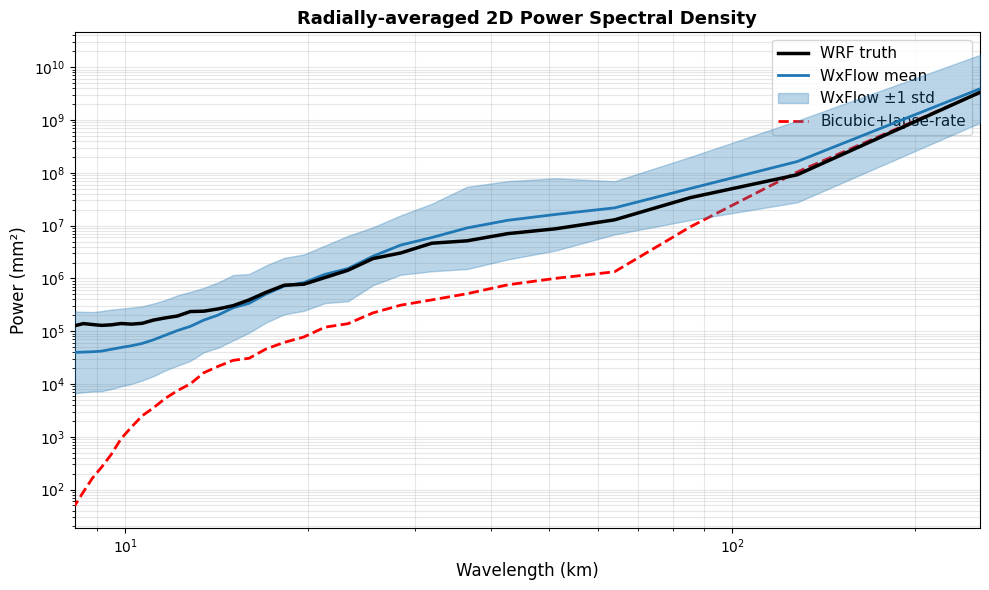


Spectral evaluation (mean absolute log10-error):
  WxFlow vs WRF truth:   0.237 (×1.73)
  Bicubic baseline vs WRF: 1.407 (×25.50)
  Spectral improvement:    83.1%

Spectral bias (signed error in log10 space):
  WxFlow:   -0.114 (×0.77)
  Bicubic:    -1.403 (×0.04)


In [17]:
def radial_psd(field_2d):
    """
    Compute radially-averaged 2D power spectral density.
    
    Args:
        field_2d: 2D numpy array of shape (n, n), may contain NaNs
    
    Returns:
        wavenumbers: 1D array of wavenumber magnitudes (pixels^-1)
        psd: 1D array of power (units^2, where units are the input field units)
    """
    n = field_2d.shape[0]
    
    # Handle NaN values: replace with field mean (common in spectral analysis)
    field_clean = field_2d.copy()
    nan_mask = np.isnan(field_clean)
    if np.any(nan_mask):
        field_mean = np.nanmean(field_clean)
        field_clean[nan_mask] = field_mean
    
    # Apply 2D Hann window to reduce spectral leakage
    win = np.outer(np.hanning(n), np.hanning(n))
    
    # FFT and power spectral density
    fft2 = np.fft.fftshift(np.fft.fft2(field_clean * win))
    power = np.abs(fft2)**2
    
    # Radial averaging: bin by distance from center
    center = n // 2
    y = np.arange(n) - center
    x = np.arange(n) - center
    yy, xx = np.meshgrid(y, x, indexing='ij')
    r = np.sqrt(xx**2 + yy**2).astype(int)
    
    # Accumulate power in radial bins
    psd = np.bincount(r.ravel(), power.ravel())
    counts = np.bincount(r.ravel())
    psd = psd / np.maximum(counts, 1)  # Avoid division by zero
    
    wavenumbers = np.arange(len(psd))
    
    return wavenumbers[1:n//2], psd[1:n//2]


# Compute PSD for all three models across ensemble members
dx = 4.0  # Grid spacing in km

# Initialize storage for spectra across tiles
k_ref = None
psd_wrf_all = []
psd_flow_all = []
psd_bicubic_all = []

for tile_idx in range(n_tiles):
    # WRF truth spectrum (single realization)
    field_wrf = xtrue_eval[tile_idx, 0].cpu().numpy() * swe_factor
    
    # Skip tiles with too much missing data
    if np.sum(np.isnan(field_wrf)) > 0.5 * n_pix * n_pix:
        print(f"Warning: tile {tile_idx} has >50% NaN coverage, skipping")
        continue
    
    k, psd_wrf = radial_psd(field_wrf)
    if k_ref is None:
        k_ref = k
    psd_wrf_all.append(psd_wrf)
    
    # WxFlow ensemble spectra
    psd_flow_members = []
    for member in range(n_eval_samples):
        field_flow = xsamp_ensemble[member, tile_idx, 0].cpu().numpy() * swe_factor
        _, psd_flow = radial_psd(field_flow)
        psd_flow_members.append(psd_flow)
    psd_flow_all.append(np.array(psd_flow_members))
    
    # Bicubic baseline ensemble spectra
    psd_bicubic_members = []
    for member in range(n_eval_samples):
        field_bicubic = xsamp_bicubic[member, tile_idx, 0].cpu().numpy() * swe_factor
        _, psd_bicubic = radial_psd(field_bicubic)
        psd_bicubic_members.append(psd_bicubic)
    psd_bicubic_all.append(np.array(psd_bicubic_members))

# Check that we have valid tiles
if len(psd_wrf_all) == 0:
    print("Error: No valid tiles for spectral analysis!")
else:
    # Average across tiles (geometric mean in log space for better representation)
    psd_wrf_mean = np.exp(np.mean(np.log(np.array(psd_wrf_all) + 1e-10), axis=0))
    psd_flow_ensemble = np.array(psd_flow_all)  # Shape: (n_tiles, n_members, n_wavenumbers)
    psd_flow_mean = np.exp(np.mean(np.log(np.mean(psd_flow_ensemble, axis=1) + 1e-10), axis=0))
    
    # Correct geometric std computation: compute std of log values across all ensemble members (flattened)
    # Reshape to (n_tiles * n_members, n_wavenumbers), then std across first axis
    psd_flow_flat = psd_flow_ensemble.reshape(-1, psd_flow_ensemble.shape[-1])
    psd_flow_logstd = np.std(np.log(psd_flow_flat + 1e-10), axis=0)  # std in log space per wavenumber
    psd_flow_std = np.exp(psd_flow_logstd)  # geometric std factor (multiplier on log plot)
    
    psd_bicubic_ensemble = np.array(psd_bicubic_all)
    psd_bicubic_mean = np.exp(np.mean(np.log(np.mean(psd_bicubic_ensemble, axis=1) + 1e-10), axis=0))
    
    # Convert wavenumber to wavelength in km
    wavelength = (n_pix * dx) / k_ref
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # WRF truth
    ax.loglog(wavelength, psd_wrf_mean, 'k-', linewidth=2.5, label='WRF truth', zorder=10)
    
    # WxFlow: mean + ensemble spread
    ax.loglog(wavelength, psd_flow_mean, color='#1f77b4', linewidth=2, label='WxFlow mean', zorder=8)
    ax.fill_between(wavelength, 
                     psd_flow_mean / psd_flow_std, 
                     psd_flow_mean * psd_flow_std,
                     alpha=0.3, color='#1f77b4', label='WxFlow ±1 std', zorder=7)
    
    # Bicubic baseline
    ax.loglog(wavelength, psd_bicubic_mean, 'r--', linewidth=2, label='Bicubic+lapse-rate', zorder=6)

    #ax.loglog(wavelength,psd_flow_flat.T,'k-',alpha=0.2)
    #ax.loglog(wavelength,np.array(psd_wrf_all).T,'r-')
    
    ax.set_xlabel('Wavelength (km)', fontsize=12)
    ax.set_ylabel('Power (mm²)', fontsize=12)
    ax.set_title('Radially-averaged 2D Power Spectral Density', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(loc='upper right', fontsize=11)
    ax.set_xlim([wavelength[-1], wavelength[0]])  # Right to left: small scale to large scale
    
    plt.tight_layout()
    fig.savefig('concept/figures/psd.png',dpi=300,bbox_inches='tight')
    plt.show()
    
    # Compute log-spectral errors (absolute)
    log_error_flow = np.mean(np.abs(np.log10(psd_flow_mean) - np.log10(psd_wrf_mean)))
    log_error_bicubic = np.mean(np.abs(np.log10(psd_bicubic_mean) - np.log10(psd_wrf_mean)))
    
    print(f"\nSpectral evaluation (mean absolute log10-error):")
    print(f"  WxFlow vs WRF truth:   {log_error_flow:.3f} (×{10**log_error_flow:.2f})")
    print(f"  Bicubic baseline vs WRF: {log_error_bicubic:.3f} (×{10**log_error_bicubic:.2f})")
    print(f"  Spectral improvement:    {(log_error_bicubic - log_error_flow) / log_error_bicubic * 100:.1f}%")
    
    # Spectral fidelity and bias: evaluate at multiple thresholds
    log_error_signed_flow = np.log10(psd_flow_mean) - np.log10(psd_wrf_mean)
    bias_flow = np.mean(log_error_signed_flow)  # positive = overpredicting, negative = underpredicting
    
    log_error_signed_bicubic = np.log10(psd_bicubic_mean) - np.log10(psd_wrf_mean)
    bias_bicubic = np.mean(log_error_signed_bicubic)
    
    thresholds = [np.log10(1.1), np.log10(1.25), np.log10(1.5)]  # log10 thresholds: ~10%, 25%, 50% error
    threshold_labels = ["10%", "25%", "50%"]
    
    print(f"\nSpectral bias (signed error in log10 space):")
    print(f"  WxFlow:   {bias_flow:+.3f} (×{10**bias_flow:.2f})")
    print(f"  Bicubic:    {bias_bicubic:+.3f} (×{10**bias_bicubic:.2f})")

Under both of the metrics above, WxFlow significantly improves over the bicubic baseline.  Evaluating the plot of wavelength against PSD, we find that WxFlow does a good job of reproducing WRF's power spectra over a bread set of wavelengths.  We note that WxFlow exhibits a small (<0.3 dB) spectral deficit at high-frequencies (on the order of 1-3 pixels).  Such a result is consistent with most generative models, which tend to have an easier time learning smooth features.  Correcting this systematic bias is an area of ongoing research.

# Conclusion
In this notebook, we have presented an application of conditional flow matching to emulating the annual maximum 3-day snowfall rates in the mountains of coastal Alaska as predicted by WRF, conditioned on high resolution topography and the low-resolution climate forcing that might be a reasonable representation of CMIP-class climate models.  We call this model WxFlow.  We find that WxFlow does a qualitatively good job of reproducing high-resolution simulations.  The distribution over its predictions is spatially coherent, with deviations from the ensemble mean governed by topography and physically-plausible effects like rain shadowing that are evident in the training data.  Under quantitative metrics like CRPS and various norms of power-spectral density, WxFlow improves significantly over a simple regression-based baseline.  Notably WxFlow produces spectral consistency with WRF, albeit while exhibiting similar low-frequency biases evident in many generative models.  Based on this evidence and previous work on generative modelling of ML-based downscaling of weather models that conditional flow matching has the potential to be an effective surrogate for a more complete representation of WRF predictions.
